### **MF05 to MF6**
---
This code was originally designed to convert the adapted (originally MODFLOW-2000) Mission Creek MODFLOW-2005 files to MODFLOW 6 files using mf5to6 [(Langevin, 2017)](https://doi.org/10.3133/tm6A55).

This example uses a model by [Mehl and Hill (2002)](https://doi.org/10.1016/S0309-1708(02)00021-0).

#### **Authorship**
*   **Author:** [Kaden McCulloch](https://www.linkedin.com)
*   **Original Date:** March 25, 2026
*   **Last Update Date:** April 13, 2026
*   **Current Version:** 1.1
    - 1.1: 
        - skip *.gdb files in the model directory copy
        - flexibility for various file extensions when building *.nam (e.g., *.bas or *.ba6)
    - 1.0: original

#### **Contact**
*   **Email:** [kaden.mcculloch@gmail.com](mailto:kaden.mcculloch@gmail.com)

---

If the code below generates something like:

"ERROR REPORT:

 FILSTAT is neither OLD nor REPLACE for file: MC_3.HDS"

 Run fix_nam_for_mf6 code in nam-writer.ipynb

In [18]:
import os
import shutil
import subprocess

# define explicit paths
exe_path = r"c:\Python\Personal\mcculloch-processors\binaries\mf5to6.exe"
source_dir = r"c:\Python\Personal\mcculloch-processors\modflow\examples\mf05-to-mf6\og-mf05\2D_SS"
target_dir = r"c:\Python\Personal\mcculloch-processors\modflow\examples\mf05-to-mf6\new-mf6\2D_SS\CHILD"

# Mehl and Hill provided two models, CHILD and PARENT
root = "CHILD"

# define file names
old_nam = f"{root}.nam"
new_nam = f"{root}_mf6" 

def run_mf6_migration_conversion():
    # create target directory
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    
    # copy all model files from source to target directory
    for filename in os.listdir(source_dir):
        if filename.lower().endswith('.gdb'):
            continue  # skip .gdb files
        shutil.copy2(os.path.join(source_dir, filename), os.path.join(target_dir, filename))

        # ... (after step 2: copy files) ...

    # build the .nam file based on existing files
    # uses dictionary mapping {Package Keyword: Extension}
    # using lowercase keys for easier matching

    potential_packages = {
        "BAS6": [".ba6", ".bas"],
        "LPF":  [".lpf"],
        "BCF6":  [".bcf"],
        "WEL":  [".wel"],
        "PCG":  [".pcg"],
        "OC":   [".oc"],
        "DIS":  [".dis", ".dis6"],
        "DRN":  [".drn"],
        "RIV":  [".riv"],
        "RCH":  [".rch"]
    }

    nam_lines = ["LIST           7  {root}.LST"]
    
    # unit numbers don't strictly matter for mf5to6, so using a simple counter
    unit_start = 10 

    for key, extensions in potential_packages.items():
        for ext in extensions:
            # check for both lowercase and uppercase versions on disk
            for final_ext in [ext, ext.upper()]:
                file_path = f"{root}{final_ext}"
                if os.path.exists(os.path.join(target_dir, file_path)):
                    nam_lines.append(f"{key:<12} {unit_start:<3} {file_path}")
                    unit_start += 1
                    break # move to next package key once a file is found

    # add standard binary output lines
    if os.path.exists(os.path.join(target_dir, "headc")):
        nam_lines.append(f"{'DATA(BINARY)':<12} 86  headc REPLACE")
    
    if os.path.exists(os.path.join(target_dir, "flowc")):
        nam_lines.append(f"{'DATA(BINARY)':<12} 87  flowc REPLACE")

    # Add the standard output replacements
    nam_lines.append(f"{'DATA(BINARY)':<12} 150 {root}.HDS REPLACE")
    nam_lines.append(f"{'DATA(BINARY)':<12} 151 {root}.DDN REPLACE")

    nam_path = os.path.join(target_dir, old_nam)
    with open(nam_path, "w") as f:
        f.write("\n".join(nam_lines))
    
    print(f"Robust .nam file generated at {target_dir}")

   # change working directory to target_dir before running EXE
    os.chdir(target_dir)

    try:
        # run the executable from its full path but within target_dir
        process = subprocess.run(
            [exe_path, old_nam, new_nam],
            capture_output=True,
            text=True,
            check=True
        )
        print("Conversion log output:")
        print(process.stdout)
        print(f"\nSuccess! Your MODFLOW 6 model is ready in {target_dir}")
        
    except subprocess.CalledProcessError as e:
        print("Error during conversion execution:")
        print(e.stderr)

if __name__ == "__main__":
    run_mf6_migration_conversion()

Robust .nam file generated at c:\Python\Personal\mcculloch-processors\modflow\examples\mf05-to-mf6\new-mf6\2D_SS\CHILD
Conversion log output:
 
 Mf5to6 - Converter for MODFLOW (2005, NWT, LGR) to MODFLOW 6
 Version 6.7.0 02/05/2026
 
 
 Converting model based on name file: CHILD.nam
 
 Processing BAS package input...
 Processing LPF package input...
 Processing OC package input...
 Processing WEL package input...
 Processing CHD package data from IBOUND input...

 CONVERSION REPORT
 Original name file: CHILD.nam
 New name file: CHILD_mf6.nam
 -------------------------------------
 Data       New       Volume Budget
 Source     Package   Table Text
 --------   -------   ----------------
 LPF        NPF       [no entry]
 IBOUND     CHD       CHD-FROM-IBOUND
 WEL        WEL       WELLS 
 -------------------------------------

 Conversion successful!
 Program terminated normally.



Success! Your MODFLOW 6 model is ready in c:\Python\Personal\mcculloch-processors\modflow\examples\mf05-to-m

Run the model after input files are successfully converted to MODFLOW 6 files. They can be deleted later, for the sake of storage space.

Run times for the Mission Creek model were about 50 seconds.

In [19]:
import flopy
import os

exe_path = r"C:\Python\Personal\mcculloch-processors\binaries\mf6.exe"
model_ws = r"c:\Python\Personal\mcculloch-processors\modflow\examples\mf05-to-mf6\new-mf6\2D_SS\CHILD"

def run_mf6_with_flopy():
    if not os.path.exists(exe_path):
        print(f"Error: MODFLOW 6 executable not found at: {exe_path}")
        return

    print("Loading and running MODFLOW 6 simulation via FloPy...")

    try:
        # use MFSimulation to load the MF6 structure
        # MF6 ignores the first argument name, it strictly looks for 'mfsim.nam'
        sim = flopy.mf6.MFSimulation.load(
            sim_name="PARENT_mf6", 
            version="mf6", 
            exe_name=exe_path, 
            sim_ws=model_ws
        )

        # execute the model
        success, buff = sim.run_simulation(silent=False, report=True)

        if success:
            print("\n" + "="*30)
            print("SUCCESS: MODFLOW 6 terminated normally.")
            print("="*30)
        else:
            print("\n" + "!"*30)
            print("FAILED: MODFLOW 6 did not finish.")
            print("Check the buffer output above for error messages.")
            print("!"*30)

    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    run_mf6_with_flopy()


Loading and running MODFLOW 6 simulation via FloPy...
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package oc...
    loading package wel...
    loading package chd...
  loading solution package child_mf6...
FloPy is using the following executable to run the model: ..\..\..\..\..\..\binaries\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/05/2026

   MODFLOW 6 compiled Feb 05 2026 22:36:44 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.6.0
                             Build 20220226_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to u

If the model runs successfully, a message should display saying "SUCCESS: MODFLOW 6 terminated normally." The code below audits the results to see if the mass balance is below an acceptable 1% limit. 

In [27]:
import flopy
import os

# path to successfully run model
list_file = r"c:\Python\Personal\mcculloch-processors\modflow\examples\mf05-to-mf6\new-mf6\2D_SS\CHILD\CHILD_mf6.lst"

def lst_audit(file_path):
    if not os.path.exists(file_path):
        print(f"Error: List file not found at {file_path}")
        return

    try:
        # fallback check for different FloPy versions
        if hasattr(flopy.mf6.utils, 'Mf6ListBudget'):
            mflist = flopy.mf6.utils.Mf6ListBudget(file_path)
        else:
            # older versions or specific builds might store it here
            from flopy.utils.mflistfile import Mf6ListBudget
            mflist = Mf6ListBudget(file_path)

        # extract the workspace and get the cumulative budget dataframe
        ws = os.path.dirname(file_path)
        sim = flopy.mf6.MFSimulation.load(sim_ws=ws, load_only=['tdis'])
        df_flux, df_vol = mflist.get_dataframes(start_datetime=sim.tdis.start_date_time.get_data())
        final_discrepancy = df_flux["PERCENT_DISCREPANCY"].iloc[-1]
        
        print("=== MODFLOW 6 LST Audit ===")
        print(f"Final Percent Discrepancy: {final_discrepancy:.4f}%")
        
        if abs(final_discrepancy) < 1.0:
            print("Status: PASS (Mass balance error is within 1%)")
        else:
            print("Status: WARNING (Mass balance error exceeds 1%)")
            
        print("\nFinal Budget Components (Fluxes):")
        print(df_flux.iloc[-1][['IN-OUT', 'TOTAL_IN', 'TOTAL_OUT']].apply(lambda x: f"{x:,.2f}"))

    except ImportError:
        print("Error: Could not locate Mf6ListBudget utility in FloPy. Please verify your FloPy version.")
    except Exception as e:
        print(f"Failed to parse LIST file: {e}")

if __name__ == "__main__":
    lst_audit(list_file)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package oc...
    skipping package wel...
    skipping package chd...
    skipping package ims6...
=== MODFLOW 6 LST Audit ===
Final Percent Discrepancy: -0.0000%
Status: PASS (Mass balance error is within 1%)

Final Budget Components (Fluxes):
IN-OUT       -0.00
TOTAL_IN      0.01
TOTAL_OUT     0.01
Name: 1.0, dtype: object


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package oc...
    loading package wel...
    loading package chd...
  loading solution package child_mf6...
Skipping RIV: Package not found in model.
Skipping DRN: Package not found in model.


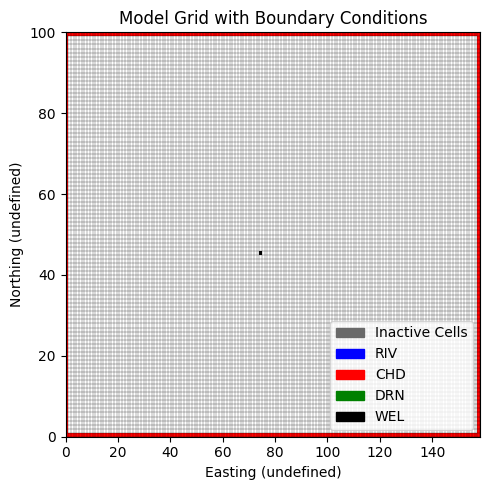

In [34]:
# plot the model grid

import matplotlib.pyplot as plt
import flopy
import matplotlib.patches as mpatches

model_ws = r"C:\Python\Personal\mcculloch-processors\modflow\examples\mf05-to-mf6\new-mf6\2D_SS\CHILD"
sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws)

def plot_grid(gwf):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # extract the grid extent from the model discretization
    grid = gwf.modelgrid
    extent = (grid.xvertices.min(), grid.xvertices.max(), 
              grid.yvertices.min(), grid.yvertices.max())

    # pass the extent
    pmv = flopy.plot.PlotMapView(model=gwf, ax=ax, extent=extent)

    # plot grid lines
    pmv.plot_grid(linewidth=0.2, color="black", alpha=1.0)

    # plot inactive cells
    pmv.plot_inactive(color_noflow='dimgray')

    # define a dictionary to map package names to colors
    bc_dict = {"RIV": "blue", "CHD": "red", "DRN": "green", "WEL": "black"}

    for name, color in bc_dict.items():
        # Check if the package exists in the model
        if gwf.get_package(name) is not None:
            pmv.plot_bc(name, color=color)
        else:
            print(f"Skipping {name}: Package not found in model.")

    # add labels
    ax.set_xlabel(f"Easting ({gwf.dis.length_units.get_data()})")
    ax.set_ylabel(f"Northing ({gwf.dis.length_units.get_data()})")

    # define custom legend handles
    legend_handles = [
    mpatches.Patch(color='dimgray', label='Inactive Cells'),
    mpatches.Patch(color='blue', label='RIV'),
    mpatches.Patch(color='red', label='CHD'),
    mpatches.Patch(color='green', label='DRN'),
    mpatches.Patch(color='black', label='WEL')
    ]  

    # pass handles to the legend
    ax.legend(handles=legend_handles, loc="lower right")
    plt.title("Model Grid with Boundary Conditions")
    plt.tight_layout()
    plt.show()

plot_grid(sim.get_model(f"{root}_mf6"))

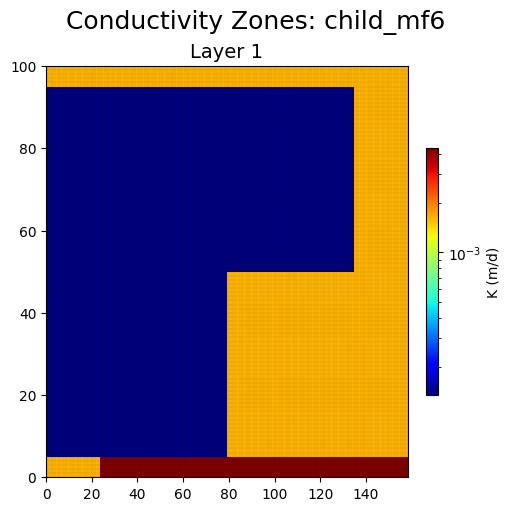

In [30]:
import math
import numpy as np

def plot_multi_layers(gwf):
    nlay = gwf.dis.nlay.get_data()
    
    # Calculate dynamic grid dimensions (e.g., 3 layers -> 1x3, 7 layers -> 2x4)
    ncols = math.ceil(math.sqrt(nlay))
    nrows = math.ceil(nlay / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), 
                             sharex=True, sharey=True, constrained_layout=True)
    
    # Ensure axes is always an array even if nlay=1
    if nlay == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    k_data = gwf.npf.k.array
    k_min = k_data[k_data > 0].min()
    k_max = k_data.max()
    log_norm = plt.matplotlib.colors.LogNorm(vmin=k_min, vmax=k_max)

    for i in range(nlay):
        ax = axes[i]
        pmv = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=i)
        
        pmv.plot_inactive(color_noflow='dimgray')
        pmv.plot_grid(linewidth=0.1, color="black", alpha=0.5)
        
        # Pass only the 2D slice for the specific layer
        hk_plot = pmv.plot_array(k_data[i], cmap='jet', norm=log_norm)
        ax.set_title(f"Layer {i+1}", fontsize=14)

    # Hide any unused subplots (e.g., if you have 7 layers in a 2x4 grid)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    # Add colorbar using the last successful plot
    cbar = fig.colorbar(hk_plot, ax=axes, orientation='vertical', shrink=0.6, label='K (m/d)')
    
    fig.suptitle(f"Conductivity Zones: {gwf.name}", fontsize=18)
    plt.show()

plot_multi_layers(sim.get_model(f"{root}_mf6"))
